## CIFAR10 TINY

In [1]:
import os

In [3]:
os.path.join('root', 'train')

'root\\train'

In [4]:
ls = [1,23]

In [5]:
list(ls)

[1, 23]

In [6]:
import collections
import math
import os
import shutil
import pandas as pd
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

In [7]:
#@save
d2l.DATA_HUB['cifar10_tiny'] = (d2l.DATA_URL + 'kaggle_cifar10_tiny.zip',
                                '2068874e4b9a9f0fb07ebe0ad2b29754449ccacd')

# 如果使用完整的Kaggle竞赛的数据集，设置demo为False
demo = True

if demo:
    data_dir = d2l.download_extract('cifar10_tiny')
else:
    data_dir = '../data/cifar-10/'

In [8]:
data_dir

'../data\\kaggle_cifar10_tiny'

In [41]:
def read_csv_labels(fname):
    with open(fname, 'r') as f:
        global lines
        lines = f.readlines()[1:]
    tokens = [l.rstrip().split(',') for l in lines]
    return dict((name, label) for name,label in tokens)

labels = read_csv_labels(os.path.join(data_dir, 'trainLabels.csv'))
labels

{'1': 'frog',
 '2': 'truck',
 '3': 'truck',
 '4': 'deer',
 '5': 'automobile',
 '6': 'automobile',
 '7': 'bird',
 '8': 'horse',
 '9': 'ship',
 '10': 'cat',
 '11': 'deer',
 '12': 'horse',
 '13': 'horse',
 '14': 'bird',
 '15': 'truck',
 '16': 'truck',
 '17': 'truck',
 '18': 'cat',
 '19': 'bird',
 '20': 'frog',
 '21': 'deer',
 '22': 'cat',
 '23': 'frog',
 '24': 'frog',
 '25': 'bird',
 '26': 'frog',
 '27': 'cat',
 '28': 'dog',
 '29': 'deer',
 '30': 'airplane',
 '31': 'airplane',
 '32': 'truck',
 '33': 'automobile',
 '34': 'cat',
 '35': 'deer',
 '36': 'airplane',
 '37': 'cat',
 '38': 'horse',
 '39': 'cat',
 '40': 'cat',
 '41': 'dog',
 '42': 'bird',
 '43': 'bird',
 '44': 'horse',
 '45': 'automobile',
 '46': 'automobile',
 '47': 'automobile',
 '48': 'bird',
 '49': 'bird',
 '50': 'airplane',
 '51': 'truck',
 '52': 'dog',
 '53': 'horse',
 '54': 'truck',
 '55': 'bird',
 '56': 'bird',
 '57': 'dog',
 '58': 'bird',
 '59': 'deer',
 '60': 'cat',
 '61': 'automobile',
 '62': 'automobile',
 '63': 'ship',

In [34]:
lines

['1,frog\n',
 '2,truck\n',
 '3,truck\n',
 '4,deer\n',
 '5,automobile\n',
 '6,automobile\n',
 '7,bird\n',
 '8,horse\n',
 '9,ship\n',
 '10,cat\n',
 '11,deer\n',
 '12,horse\n',
 '13,horse\n',
 '14,bird\n',
 '15,truck\n',
 '16,truck\n',
 '17,truck\n',
 '18,cat\n',
 '19,bird\n',
 '20,frog\n',
 '21,deer\n',
 '22,cat\n',
 '23,frog\n',
 '24,frog\n',
 '25,bird\n',
 '26,frog\n',
 '27,cat\n',
 '28,dog\n',
 '29,deer\n',
 '30,airplane\n',
 '31,airplane\n',
 '32,truck\n',
 '33,automobile\n',
 '34,cat\n',
 '35,deer\n',
 '36,airplane\n',
 '37,cat\n',
 '38,horse\n',
 '39,cat\n',
 '40,cat\n',
 '41,dog\n',
 '42,bird\n',
 '43,bird\n',
 '44,horse\n',
 '45,automobile\n',
 '46,automobile\n',
 '47,automobile\n',
 '48,bird\n',
 '49,bird\n',
 '50,airplane\n',
 '51,truck\n',
 '52,dog\n',
 '53,horse\n',
 '54,truck\n',
 '55,bird\n',
 '56,bird\n',
 '57,dog\n',
 '58,bird\n',
 '59,deer\n',
 '60,cat\n',
 '61,automobile\n',
 '62,automobile\n',
 '63,ship\n',
 '64,bird\n',
 '65,automobile\n',
 '66,automobile\n',
 '67,dee

In [35]:
tokens = [l.rstrip().split(',') for l in lines]
tokens

[['1', 'frog'],
 ['2', 'truck'],
 ['3', 'truck'],
 ['4', 'deer'],
 ['5', 'automobile'],
 ['6', 'automobile'],
 ['7', 'bird'],
 ['8', 'horse'],
 ['9', 'ship'],
 ['10', 'cat'],
 ['11', 'deer'],
 ['12', 'horse'],
 ['13', 'horse'],
 ['14', 'bird'],
 ['15', 'truck'],
 ['16', 'truck'],
 ['17', 'truck'],
 ['18', 'cat'],
 ['19', 'bird'],
 ['20', 'frog'],
 ['21', 'deer'],
 ['22', 'cat'],
 ['23', 'frog'],
 ['24', 'frog'],
 ['25', 'bird'],
 ['26', 'frog'],
 ['27', 'cat'],
 ['28', 'dog'],
 ['29', 'deer'],
 ['30', 'airplane'],
 ['31', 'airplane'],
 ['32', 'truck'],
 ['33', 'automobile'],
 ['34', 'cat'],
 ['35', 'deer'],
 ['36', 'airplane'],
 ['37', 'cat'],
 ['38', 'horse'],
 ['39', 'cat'],
 ['40', 'cat'],
 ['41', 'dog'],
 ['42', 'bird'],
 ['43', 'bird'],
 ['44', 'horse'],
 ['45', 'automobile'],
 ['46', 'automobile'],
 ['47', 'automobile'],
 ['48', 'bird'],
 ['49', 'bird'],
 ['50', 'airplane'],
 ['51', 'truck'],
 ['52', 'dog'],
 ['53', 'horse'],
 ['54', 'truck'],
 ['55', 'bird'],
 ['56', 'bird'],
 [

In [16]:
import pandas as pd
import numpy as np
datadf = pd.read_csv(os.path.join(data_dir, 'trainLabels.csv'))


In [39]:
labels = [i for i in datadf['label']]
labels

['frog',
 'truck',
 'truck',
 'deer',
 'automobile',
 'automobile',
 'bird',
 'horse',
 'ship',
 'cat',
 'deer',
 'horse',
 'horse',
 'bird',
 'truck',
 'truck',
 'truck',
 'cat',
 'bird',
 'frog',
 'deer',
 'cat',
 'frog',
 'frog',
 'bird',
 'frog',
 'cat',
 'dog',
 'deer',
 'airplane',
 'airplane',
 'truck',
 'automobile',
 'cat',
 'deer',
 'airplane',
 'cat',
 'horse',
 'cat',
 'cat',
 'dog',
 'bird',
 'bird',
 'horse',
 'automobile',
 'automobile',
 'automobile',
 'bird',
 'bird',
 'airplane',
 'truck',
 'dog',
 'horse',
 'truck',
 'bird',
 'bird',
 'dog',
 'bird',
 'deer',
 'cat',
 'automobile',
 'automobile',
 'ship',
 'bird',
 'automobile',
 'automobile',
 'deer',
 'truck',
 'horse',
 'ship',
 'dog',
 'truck',
 'frog',
 'horse',
 'cat',
 'automobile',
 'truck',
 'airplane',
 'cat',
 'automobile',
 'cat',
 'dog',
 'deer',
 'dog',
 'horse',
 'horse',
 'deer',
 'horse',
 'truck',
 'deer',
 'bird',
 'cat',
 'ship',
 'airplane',
 'automobile',
 'frog',
 'automobile',
 'automobile',
 

In [25]:
ids = [str(i) for i in datadf['id']]
ids

['1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '13

In [40]:
dict( zip(ids, labels))

{'1': 'frog',
 '2': 'truck',
 '3': 'truck',
 '4': 'deer',
 '5': 'automobile',
 '6': 'automobile',
 '7': 'bird',
 '8': 'horse',
 '9': 'ship',
 '10': 'cat',
 '11': 'deer',
 '12': 'horse',
 '13': 'horse',
 '14': 'bird',
 '15': 'truck',
 '16': 'truck',
 '17': 'truck',
 '18': 'cat',
 '19': 'bird',
 '20': 'frog',
 '21': 'deer',
 '22': 'cat',
 '23': 'frog',
 '24': 'frog',
 '25': 'bird',
 '26': 'frog',
 '27': 'cat',
 '28': 'dog',
 '29': 'deer',
 '30': 'airplane',
 '31': 'airplane',
 '32': 'truck',
 '33': 'automobile',
 '34': 'cat',
 '35': 'deer',
 '36': 'airplane',
 '37': 'cat',
 '38': 'horse',
 '39': 'cat',
 '40': 'cat',
 '41': 'dog',
 '42': 'bird',
 '43': 'bird',
 '44': 'horse',
 '45': 'automobile',
 '46': 'automobile',
 '47': 'automobile',
 '48': 'bird',
 '49': 'bird',
 '50': 'airplane',
 '51': 'truck',
 '52': 'dog',
 '53': 'horse',
 '54': 'truck',
 '55': 'bird',
 '56': 'bird',
 '57': 'dog',
 '58': 'bird',
 '59': 'deer',
 '60': 'cat',
 '61': 'automobile',
 '62': 'automobile',
 '63': 'ship',

In [46]:
labels.values()

dict_values(['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat', 'deer', 'horse', 'horse', 'bird', 'truck', 'truck', 'truck', 'cat', 'bird', 'frog', 'deer', 'cat', 'frog', 'frog', 'bird', 'frog', 'cat', 'dog', 'deer', 'airplane', 'airplane', 'truck', 'automobile', 'cat', 'deer', 'airplane', 'cat', 'horse', 'cat', 'cat', 'dog', 'bird', 'bird', 'horse', 'automobile', 'automobile', 'automobile', 'bird', 'bird', 'airplane', 'truck', 'dog', 'horse', 'truck', 'bird', 'bird', 'dog', 'bird', 'deer', 'cat', 'automobile', 'automobile', 'ship', 'bird', 'automobile', 'automobile', 'deer', 'truck', 'horse', 'ship', 'dog', 'truck', 'frog', 'horse', 'cat', 'automobile', 'truck', 'airplane', 'cat', 'automobile', 'cat', 'dog', 'deer', 'dog', 'horse', 'horse', 'deer', 'horse', 'truck', 'deer', 'bird', 'cat', 'ship', 'airplane', 'automobile', 'frog', 'automobile', 'automobile', 'deer', 'automobile', 'ship', 'cat', 'truck', 'frog', 'frog', 'automobile', 'ship', 'd

In [47]:
collections.Counter(labels.values())

Counter({'automobile': 112,
         'frog': 107,
         'truck': 103,
         'horse': 102,
         'airplane': 102,
         'deer': 99,
         'bird': 99,
         'ship': 99,
         'cat': 92,
         'dog': 85})

In [58]:
dict(zip(datadf['label'].value_counts().index,datadf['label'].value_counts()[:]))


{'automobile': 112,
 'frog': 107,
 'truck': 103,
 'horse': 102,
 'airplane': 102,
 'deer': 99,
 'bird': 99,
 'ship': 99,
 'cat': 92,
 'dog': 85}

In [59]:
collections.Counter(labels.values()).most_common()

[('automobile', 112),
 ('frog', 107),
 ('truck', 103),
 ('horse', 102),
 ('airplane', 102),
 ('deer', 99),
 ('bird', 99),
 ('ship', 99),
 ('cat', 92),
 ('dog', 85)]

In [61]:
collections.Counter(labels.values()).most_common()[-1][1]

85

In [63]:
os.listdir(os.path.join(data_dir, 'train'))[:5]

['1.png', '10.png', '100.png', '1000.png', '101.png']

In [75]:
pd.read_csv(os.path.join(data_dir,'trainLabels.csv'),index_col=0).iloc[0,0]

'frog'

In [81]:
labels.get(1,0)

0

In [1]:
'123'[0]

'1'

In [4]:
for i in dict(((1,33),(2,66))):  #输出的是键
    print(i)

1
2


In [82]:
def copyfile(filename, target_dir):
    os.makedirs(target_dir, exist_ok=True)  # 当存在时不会抛出异常
    shutil.copy(filename, target_dir)

def reorg_train_valid(data_dir, labels, valid_ratio):
    """将验证集从原始的训练集中拆分出来"""
    # 训练数据集中样本最少的类别中的样本数
    n = collections.Counter(labels.values()).most_common()[-1][1]
    # 验证集中每个类别的样本数
    n_valid_per_label = max(1, math.floor(n * valid_ratio))
    label_count = {}
    for train_file in os.listdir(os.path.join(data_dir, 'train')):
        label = labels[train_file.split('.')[0]]
        fname = os.path.join(data_dir, 'train', train_file)
        copyfile(fname, os.path.join(data_dir, 'train_valid_test',
                                     'train_valid', label))
        if label not in label_count or label_count[label] < n_valid_per_label:
            copyfile(fname, os.path.join(data_dir, 'train_valid_test',
                                         'valid', label)) # 就把该文件存在path.join后面那个网址
            label_count[label] = label_count.get(label, 0) + 1 # 如果label不存在返回0
        else:
            copyfile(fname, os.path.join(data_dir, 'train_valid_test',
                                         'train', label))
    return n_valid_per_label

In [83]:
#@save
def reorg_test(data_dir):
    """在预测期间整理测试集，以方便读取"""
    for test_file in os.listdir(os.path.join(data_dir, 'test')):
        copyfile(os.path.join(data_dir, 'test', test_file),
                 os.path.join(data_dir, 'train_valid_test', 'test',
                              'unknown'))

In [84]:
def reorg_cifar10_data(data_dir, valid_ratio):
    labels = read_csv_labels(os.path.join(data_dir, 'trainLabels.csv'))
    reorg_train_valid(data_dir, labels, valid_ratio)
    reorg_test(data_dir)

In [85]:
batch_size = 32 if demo else 128
valid_ratio = 0.1
reorg_cifar10_data(data_dir, valid_ratio)

In [86]:
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.Resize(40)
    ,torchvision.transforms.RandomResizedCrop(32,scale=(0.64,1),ratio=(1,1))
    ,torchvision.transforms.RandomHorizontalFlip()
    ,torchvision.transforms.ToTensor(),
    # 标准化图像的每个通道
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                     [0.2023, 0.1994, 0.2010])]) #这是均值和标准差

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                     [0.2023, 0.1994, 0.2010])])

In [87]:
train_ds, train_valid_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=transform_train) for folder in ['train', 'train_valid']] # 将文件夹名当做标签 并且自动变成数字

valid_ds, test_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=transform_test) for folder in ['valid', 'test']]

In [88]:
train_iter, train_valid_iter = [torch.utils.data.DataLoader(
    dataset, batch_size, shuffle=True, drop_last=True) # 将最后的剩下的不足的batchsize扔掉
    for dataset in (train_ds, train_valid_ds)]

valid_iter = torch.utils.data.DataLoader(valid_ds, batch_size, shuffle=False,
                                         drop_last=True)

test_iter = torch.utils.data.DataLoader(test_ds, batch_size, shuffle=False,
                                        drop_last=False)

In [89]:
def get_net():
    num_classes = 10
    net = d2l.resnet18(num_classes, 3)
    return net

loss = nn.CrossEntropyLoss(reduction="none")

In [90]:
def train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
          lr_decay):
    trainer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9,
                              weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_period, lr_decay)  # 一般来说一开始训练学习率比较大，最后快到结果了就要踩刹车降低学习率
    # 每隔lr_period个epoch学习率乘以lr_decay
    num_batches, timer = len(train_iter), d2l.Timer()
    legend = ['train loss', 'train acc']
    if valid_iter is not None:
        legend.append('valid acc')
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=legend)
    net = nn.DataParallel(net, device_ids=devices).to(devices[0]) #记得存到统一的devices里进行并行
    for epoch in range(num_epochs):
        net.train()
        metric = d2l.Accumulator(3)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = d2l.train_batch_ch13(net, features, labels,
                                          loss, trainer, devices)
            metric.add(l, acc, labels.shape[0])
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2],
                              None))
        if valid_iter is not None:
            valid_acc = d2l.evaluate_accuracy_gpu(net, valid_iter)
            animator.add(epoch + 1, (None, None, valid_acc))
        scheduler.step() # 每个epoch以后step一下
    measures = (f'train loss {metric[0] / metric[2]:.3f}, '
                f'train acc {metric[1] / metric[2]:.3f}')
    if valid_iter is not None:
        measures += f', valid acc {valid_acc:.3f}'
    print(measures + f'\n{metric[2] * num_epochs / timer.sum():.1f}'
          f' examples/sec on {str(devices)}')

train loss 0.521, train acc 0.827, valid acc 0.391
1370.4 examples/sec on [device(type='cuda', index=0)]


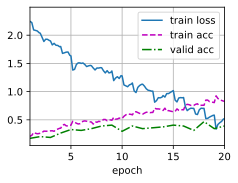

In [91]:
devices, num_epochs, lr, wd = d2l.try_all_gpus(), 20, 2e-4, 5e-4
lr_period, lr_decay, net = 4, 0.9, get_net()
train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
      lr_decay)

train loss 0.504, train acc 0.827
1449.0 examples/sec on [device(type='cuda', index=0)]


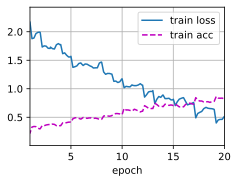

In [92]:
net, preds = get_net(), []
train(net, train_valid_iter, None, num_epochs, lr, wd, devices, lr_period,
      lr_decay)

for X, _ in test_iter:
    y_hat = net(X.to(devices[0]))
    preds.extend(y_hat.argmax(dim=1).type(torch.int32).cpu().numpy())
sorted_ids = list(range(1, len(test_ds) + 1))
sorted_ids.sort(key=lambda x: str(x)) # 根据字符串的大小排序
df = pd.DataFrame({'id': sorted_ids, 'label': preds})
df['label'] = df['label'].apply(lambda x: train_valid_ds.classes[x]) # 对应到各自的label中
df.to_csv('../data/kaggle_cifar10_tiny/submission.csv', index=False)

In [97]:
y_hat.shape

torch.Size([5, 10])

In [105]:
train_valid_ds.classes  # 这是imagefolder的结果 里面通过调用classes属性能够得到对应的标签

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [99]:
y_hat.argmax(axis=1)

tensor([8, 4, 7, 6, 3], device='cuda:0')

In [100]:
y_hat.max(axis=1)

torch.return_types.max(
values=tensor([7.8986, 5.1507, 4.2119, 6.7601, 2.8108], device='cuda:0',
       grad_fn=<MaxBackward0>),
indices=tensor([8, 4, 7, 6, 3], device='cuda:0'))

In [101]:
sorted_ids

[1, 2, 3, 4, 5]

In [103]:
sorted_ids.sort(key=lambda x: str(x))
sorted_ids

[1, 2, 3, 4, 5]

## ImageNet Dogs

In [5]:
import os
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

In [6]:
#@save
d2l.DATA_HUB['dog_tiny'] = (d2l.DATA_URL + 'kaggle_dog_tiny.zip',
                            '0cb91d09b814ecdc07b50f31f8dcad3e81d6a86d')

# 如果使用Kaggle比赛的完整数据集，请将下面的变量更改为False
demo = True
if demo:
    data_dir = d2l.download_extract('dog_tiny')
else:
    data_dir = os.path.join('..', 'data', 'dog-breed-identification')

In [7]:
def reorg_dog_data(data_dir, valid_ratio):
    labels = d2l.read_csv_labels(os.path.join(data_dir, 'labels.csv'))
    d2l.reorg_train_valid(data_dir, labels, valid_ratio)
    d2l.reorg_test(data_dir)


batch_size = 32 if demo else 128
valid_ratio = 0.1
reorg_dog_data(data_dir, valid_ratio)

In [8]:
transform_train = torchvision.transforms.Compose([
    # 随机裁剪图像，所得图像为原始面积的0.08～1之间，高宽比在3/4和4/3之间。
    # 然后，缩放图像以创建224x224的新图像
    torchvision.transforms.RandomResizedCrop(224, scale=(0.08, 1.0),
                                             ratio=(3.0/4.0, 4.0/3.0)),
    torchvision.transforms.RandomHorizontalFlip(),
    # 随机更改亮度，对比度和饱和度
    torchvision.transforms.ColorJitter(brightness=0.4,
                                       contrast=0.4,
                                       saturation=0.4),
    # 添加随机噪声
    torchvision.transforms.ToTensor(),
    # 标准化图像的每个通道
    torchvision.transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])])

In [10]:
transform_test = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    # 如果是一个 sequence: [h, w]，则表示将图像缩放到该尺寸，不保持原始图像的宽高比。
    # 如果是 int，表示将图像的较小边的长度将设置为这个数值，同时保持原始的宽高比，
    # 从图像中心裁切224x224大小的图片
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])])

In [11]:
train_ds, train_valid_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=transform_train) for folder in ['train', 'train_valid']]

valid_ds, test_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=transform_test) for folder in ['valid', 'test']]

In [12]:
train_iter, train_valid_iter = [torch.utils.data.DataLoader(
    dataset, batch_size, shuffle=True, drop_last=True)
    for dataset in (train_ds, train_valid_ds)]

valid_iter = torch.utils.data.DataLoader(valid_ds, batch_size, shuffle=False,
                                         drop_last=True)

test_iter = torch.utils.data.DataLoader(test_ds, batch_size, shuffle=False,
                                        drop_last=False)

In [13]:
def get_net(devices):
    finetune_net = nn.Sequential()
    finetune_net.features = torchvision.models.resnet34(pretrained=True)
    # 定义一个新的输出网络，共有120个输出类别
    finetune_net.output_new = nn.Sequential(nn.Linear(1000, 256),
                                            nn.ReLU(),
                                            nn.Linear(256, 120))
    # 将模型参数分配给用于计算的CPU或GPU
    finetune_net = finetune_net.to(devices[0])
    # 冻结参数
    for param in finetune_net.features.parameters():
        param.requires_grad = False  # 将grad取消就是冻结
    return finetune_net

In [14]:
torchvision.models.resnet34(pretrained=True)

D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Pycharm\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\Lollipop/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|█████████████████████████████████████████████████████████████████████████████| 83.3M/83.3M [00:43<00:00, 2.00MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
finetune_net = nn.Sequential()
finetune_net

Sequential()

In [18]:
finetune_net.features = torchvision.models.resnet34(pretrained=True)
finetune_net

Sequential(
  (features): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
# 注意这里resnet34的fc是输出1000的 所以后续多加的线性层也是输入通道式1000的
# 相当于用resnet34作为特征提取 然后自己后续加了全连接作为分类
# 这里的features和output_new都是自己定义的名字，可以理解为块的名字

In [19]:
loss = nn.CrossEntropyLoss(reduction='none')

def evaluate_loss(data_iter, net, devices):
    l_sum, n = 0.0, 0
    for features, labels in data_iter:
        features, labels = features.to(devices[0]), labels.to(devices[0])
        outputs = net(features)
        l = loss(outputs, labels)
        l_sum += l.sum()
        n += labels.numel()
    return (l_sum / n).to('cpu')

In [20]:
def train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
          lr_decay):
    # 只训练小型自定义输出网络
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    trainer = torch.optim.SGD((param for param in net.parameters()
                               if param.requires_grad), lr=lr,
                              momentum=0.9, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_period, lr_decay)
    num_batches, timer = len(train_iter), d2l.Timer()
    legend = ['train loss']
    if valid_iter is not None:
        legend.append('valid loss')
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=legend)
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(2)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            features, labels = features.to(devices[0]), labels.to(devices[0])
            trainer.zero_grad()
            output = net(features)
            l = loss(output, labels).sum()
            l.backward()
            trainer.step()
            metric.add(l, labels.shape[0])
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1], None))
        measures = f'train loss {metric[0] / metric[1]:.3f}'
        if valid_iter is not None:
            valid_loss = evaluate_loss(valid_iter, net, devices)
            animator.add(epoch + 1, (None, valid_loss.detach().cpu()))
        scheduler.step()
    if valid_iter is not None:
        measures += f', valid loss {valid_loss:.3f}'
    print(measures + f'\n{metric[1] * num_epochs / timer.sum():.1f}'
          f' examples/sec on {str(devices)}')

train loss 1.085, valid loss 1.474
511.8 examples/sec on [device(type='cuda', index=0)]


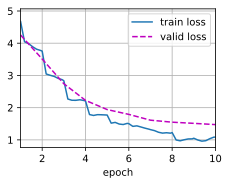

In [21]:
devices, num_epochs, lr, wd = d2l.try_all_gpus(), 10, 1e-4, 1e-4
lr_period, lr_decay, net = 2, 0.9, get_net(devices)
train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
      lr_decay)

train loss 1.032
393.5 examples/sec on [device(type='cuda', index=0)]


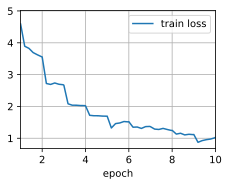

In [22]:
net = get_net(devices)
train(net, train_valid_iter, None, num_epochs, lr, wd, devices, lr_period,
      lr_decay)

preds = []
for data, label in test_iter:
    output = torch.nn.functional.softmax(net(data.to(devices[0])), dim=1)
    preds.extend(output.cpu().detach().numpy())
ids = sorted(os.listdir(
    os.path.join(data_dir, 'train_valid_test', 'test', 'unknown')))
with open('../data/kaggle_dog_tiny/submission.csv', 'w') as f:
    f.write('id,' + ','.join(train_valid_ds.classes) + '\n')
    for i, output in zip(ids, preds):
        f.write(i.split('.')[0] + ',' + ','.join(
            [str(num) for num in output]) + '\n')